# Car Price Prediction using Machine Learning
### A College-Level Data Science Mini Project

---

**Course:** Data Science / Machine Learning  
**Algorithm Used:** Linear Regression  
**Dataset:** CarPrice_Assignment.csv (205 rows × 26 columns)  
**Target Variable:** `price`

---
> **Project Goal:** Build a supervised machine learning model that predicts the selling price of a car based on its physical and technical specifications.


## 1.Problem Understanding
*(Evaluation Criterion 1 — 2 Marks)*

---

### What is the Business Problem?

The automobile industry is highly competitive. Car manufacturers and dealers need to understand **what factors drive car prices** so they can:
- Set competitive prices for new models
- Identify which features add the most value
- Make data-driven manufacturing decisions

### Objective

> Build a **Linear Regression model** that accurately predicts the price of a car based on its features such as engine size, horsepower, fuel type, body style, and more.

### Type of Machine Learning Problem

| Property | Detail |
|---|---|
| Problem Type | Supervised Learning |
| Task | Regression (predicting a continuous value) |
| Target Variable | `price` (in USD) |
| Input Features | 25 numerical & categorical columns |

### Why Linear Regression?

Linear Regression is the **most fundamental regression algorithm**. It assumes a linear relationship between input features and the target variable. It is:
- Easy to interpret
- Computationally efficient
- A great baseline model for regression tasks


## 2.Import Libraries
*(Best Practice: Import all libraries at the top of the notebook)*

We import the following categories of libraries:
- **Data handling:** `pandas`, `numpy`
- **Visualization:** `matplotlib`, `seaborn`
- **Machine Learning:** `scikit-learn`


In [51]:
#  Standard Data Science Libraries 
import pandas as pd                          # Data manipulation and analysis
import numpy as np                           # Numerical operations

#  Visualization Libraries 
import matplotlib.pyplot as plt              # Plotting graphs
import seaborn as sns                        # Statistical visualizations

#  Machine Learning Libraries 
from sklearn.model_selection import train_test_split   # Split data into train/test
from sklearn.preprocessing import StandardScaler       # Feature scaling
from sklearn.preprocessing import LabelEncoder         # Encode categorical variables
from sklearn.linear_model import LinearRegression      # Our ML model
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)
print("All libraries imported successfully!")

All libraries imported successfully!


**Interpretation:**  
All libraries are loaded. 


## 3. Load Dataset

We load the CSV dataset using `pandas.read_csv()`. The dataset is stored locally after upload.


In [52]:
try:
    # Try loading from uploaded/local path
    df = pd.read_csv('CarPrice_Assignment.csv')
    print("Dataset loaded from uploaded file")
except:
    # Fallback: load from GitHub URL
    url = "https://raw.githubusercontent.com/ameenmanna8824/DATASETS/main/CarPrice_Assignment.csv"
    df = pd.read_csv(url)
    print("Dataset loaded from GitHub URL")
# Confirm dataset
print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")

Dataset loaded from uploaded file
Shape: 205 rows × 26 columns


**Interpretation:**  
The dataset has **205 rows** (cars) and **26 columns** (features + target). Each row represents one car model.


## 4.Initial Dataset Exploration
*(Evaluation Criterion 2 — 2 Marks)*

### Step 4.1 — View First 5 Rows


In [53]:
# Display the first 5 rows to understand data structure
df.head()


,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,carlength,carwidth,carheight,curbweight,enginetype,cylindernumber,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,171.2,65.5,52.4,2823,ohcv,six,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,176.6,66.2,54.3,2337,ohc,four,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,176.6,66.4,54.3,2824,ohc,five,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


**Interpretation:**  
We can see the dataset has both **text columns** (CarName, fueltype, carbody) and **numeric columns** (wheelbase, horsepower, price). The last column `price` is our **target variable**.

---
### Step 4.2 — Dataset Info


In [54]:
# Check data types and non-null counts for every column
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   CarName           205 non-null    object 
 3   fueltype          205 non-null    object 
 4   aspiration        205 non-null    object 
 5   doornumber        205 non-null    object 
 6   carbody           205 non-null    object 
 7   drivewheel        205 non-null    object 
 8   enginelocation    205 non-null    object 
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    object 
 15  cylindernumber    205 non-null    object 
 16  enginesize        205 non-null    int64  
 1

**Interpretation:**  
- All 26 columns have **205 non-null entries** → No missing values ✅  
- Columns like `fueltype`, `carbody`, `CarName` are **object (string)** dtype → need encoding  
- Numeric columns are already `int64` or `float64` → ready for modelling

---
### Step 4.3 — Statistical Summary


In [55]:
# Descriptive statistics for all numerical columns
df.describe().round(2)


,car_ID,symboling,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
count,205.00,205.00,205.00,205.00,205.00,205.00,205.00,205.00,205.00,205.00,205.00,205.00,205.00,205.00,205.00,205.00
mean,103.00,0.83,98.76,174.05,65.91,53.72,2555.57,126.91,3.33,3.26,10.14,104.12,5125.12,25.22,30.75,13276.71
std,59.32,1.25,6.02,12.34,2.15,2.44,520.68,41.64,0.27,0.31,3.97,39.54,476.99,6.54,6.89,7988.85
min,1.00,-2.00,86.60,141.10,60.30,47.80,1488.00,61.00,2.54,2.07,7.00,48.00,4150.00,13.00,16.00,5118.00
25%,52.00,0.00,94.50,166.30,64.10,52.00,2145.00,97.00,3.15,3.11,8.60,70.00,4800.00,19.00,25.00,7788.00
50%,103.00,1.00,97.00,173.20,65.50,54.10,2414.00,120.00,3.31,3.29,9.00,95.00,5200.00,24.00,30.00,10295.00
75%,154.00,2.00,102.40,183.10,66.90,55.50,2935.00,141.00,3.58,3.41,9.40,116.00,5500.00,30.00,34.00,16503.00
max,205.00,3.00,120.90,208.10,72.30,59.80,4066.00,326.00,3.94,4.17,23.00,288.00,6600.00,49.00,54.00,45400.00


**Interpretation (Key Observations):**

| Feature | Observation |
|---|---|
| `price` | Ranges from ~$5,118 to ~$45,400 — wide range, indicating diversity |
| `horsepower` | Mean ≈ 104 HP; some high-performance cars reach 288 HP |
| `enginesize` | Mean ≈ 127 cc; large variance suggests different car segments |
| `citympg` | Mean ≈ 25 mpg — useful feature for price correlation |

The wide standard deviations suggest **feature scaling will be important** before modelling.


## 5.Understanding Dataset Features

### Step 5.1 — Identify Numerical vs Categorical Columns


In [56]:
# Separate columns by data type
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print("Numerical Columns ({} total):".format(len(numerical_cols)))
for c in numerical_cols:
    print(f"   • {c}")

print()
print("Categorical Columns ({} total):".format(len(categorical_cols)))
for c in categorical_cols:
    print(f"   • {c}")


Numerical Columns (16 total):
   • car_ID
   • symboling
   • wheelbase
   • carlength
   • carwidth
   • carheight
   • curbweight
   • enginesize
   • boreratio
   • stroke
   • compressionratio
   • horsepower
   • peakrpm
   • citympg
   • highwaympg
   • price

Categorical Columns (10 total):
   • CarName
   • fueltype
   • aspiration
   • doornumber
   • carbody
   • drivewheel
   • enginelocation
   • enginetype
   • cylindernumber
   • fuelsystem


**Interpretation:**  
- **Numerical features** (16): directly usable after scaling  
- **Categorical features** (10): must be encoded into numbers before modelling  
- `car_ID` is an identifier column — it will be **dropped** as it has no predictive value

---
### Step 5.2 — Target Variable Distribution


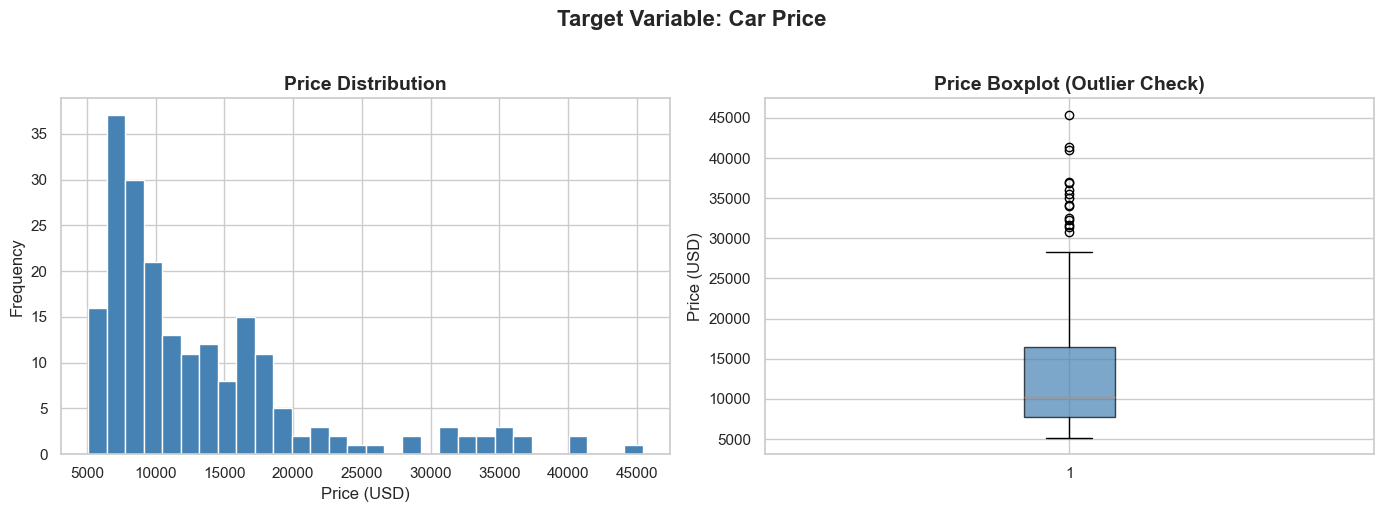

Chart saved.


In [57]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of price
axes[0].hist(df['price'], bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Price Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Price (USD)')
axes[0].set_ylabel('Frequency')

# Boxplot of price
axes[1].boxplot(df['price'], vert=True, patch_artist=True,
boxprops=dict(facecolor='steelblue', alpha=0.7))
axes[1].set_title('Price Boxplot (Outlier Check)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Price (USD)')

plt.suptitle('Target Variable: Car Price', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('01_price_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")


**Interpretation:**  
- Price distribution is **right-skewed** — most cars are in the lower price range with a few luxury/premium outliers  
- The boxplot confirms **outliers on the higher end**, which is expected in a real-world car dataset  
- Linear Regression can still work but may be slightly affected by extreme outliers


## 6. Data Cleaning

### Step 6.1 — Check for Missing Values


In [58]:
# Check for missing values in each column
missing = df.isnull().sum()
print("Missing Values Per Column:")
print(missing[missing > 0] if missing.sum() > 0 else "No missing values found!")


Missing Values Per Column:
No missing values found!


**Interpretation:**  
The dataset has **zero missing values** — no imputation required. This is ideal for a clean analysis.

---
### Step 6.2 — Check for Duplicate Rows


In [59]:
# Check for duplicate rows
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")
if duplicates == 0:
    print("No duplicate rows found!")
else:
    df.drop_duplicates(inplace=True)
    print(f"Removed {duplicates} duplicate rows.")


Number of duplicate rows: 0
No duplicate rows found!


**Interpretation:**  
No duplicate rows found. The dataset is already clean and ready for preprocessing.

---
### Step 6.3 — Drop Irrelevant Column


In [60]:
# Drop 'car_ID' — it's just a serial number, not a predictive feature
df.drop(columns=['car_ID'], inplace=True)
print(f"'car_ID' column dropped. New shape: {df.shape}")


'car_ID' column dropped. New shape: (205, 25)


## 7.Feature Engineering

### Step 7.1 — Extract Car Brand from CarName

The `CarName` column contains values like `"toyota corolla"`, `"honda civic"`, etc.  
We extract only the **brand name** (first word), which is far more useful as a feature.


In [61]:
# Extract brand name (first word) from the CarName column
df['brand'] = df['CarName'].apply(lambda x: x.split()[0].lower().strip())

# View the unique brand names before cleaning
print("Unique brands found:")
print(sorted(df['brand'].unique()))


Unique brands found:
['alfa-romero', 'audi', 'bmw', 'buick', 'chevrolet', 'dodge', 'honda', 'isuzu', 'jaguar', 'maxda', 'mazda', 'mercury', 'mitsubishi', 'nissan', 'peugeot', 'plymouth', 'porcshce', 'porsche', 'renault', 'saab', 'subaru', 'toyota', 'toyouta', 'vokswagen', 'volkswagen', 'volvo', 'vw']


**Observation:**  
Some brand names have typos (e.g., `maxda` instead of `mazda`, `vw` instead of `volkswagen`). We fix these below.

---
### Step 7.2 — Fix Brand Name Typos


In [62]:
# Dictionary to fix common spelling mistakes in car brand names
brand_fix = {
    'maxda': 'mazda',
    'porcshce': 'porsche',
    'toyouta': 'toyota',
    'vokswagen': 'volkswagen',
    'vw': 'volkswagen'
}

# Replace incorrect brand names with correct ones
df['brand'] = df['brand'].replace(brand_fix)

# Drop the original CarName column since brand is extracted
df.drop(columns=['CarName'], inplace=True)

# Verify results
print("Brand names cleaned successfully")
print("\nUnique brands after cleaning:")
print(sorted(df['brand'].unique()))

print(f"\nTotal unique brands: {df['brand'].nunique()}")

Brand names cleaned successfully

Unique brands after cleaning:
['alfa-romero', 'audi', 'bmw', 'buick', 'chevrolet', 'dodge', 'honda', 'isuzu', 'jaguar', 'mazda', 'mercury', 'mitsubishi', 'nissan', 'peugeot', 'plymouth', 'porsche', 'renault', 'saab', 'subaru', 'toyota', 'volkswagen', 'volvo']

Total unique brands: 22


**Interpretation:**  
We now have a clean `brand` column with **22 unique car manufacturers**. This is a much more useful feature than the full model name.


## 8.Exploratory Data Analysis (EDA)

EDA helps us understand relationships between features and the target variable `price`.

### Step 8.1 — Correlation Heatmap (Numerical Features)


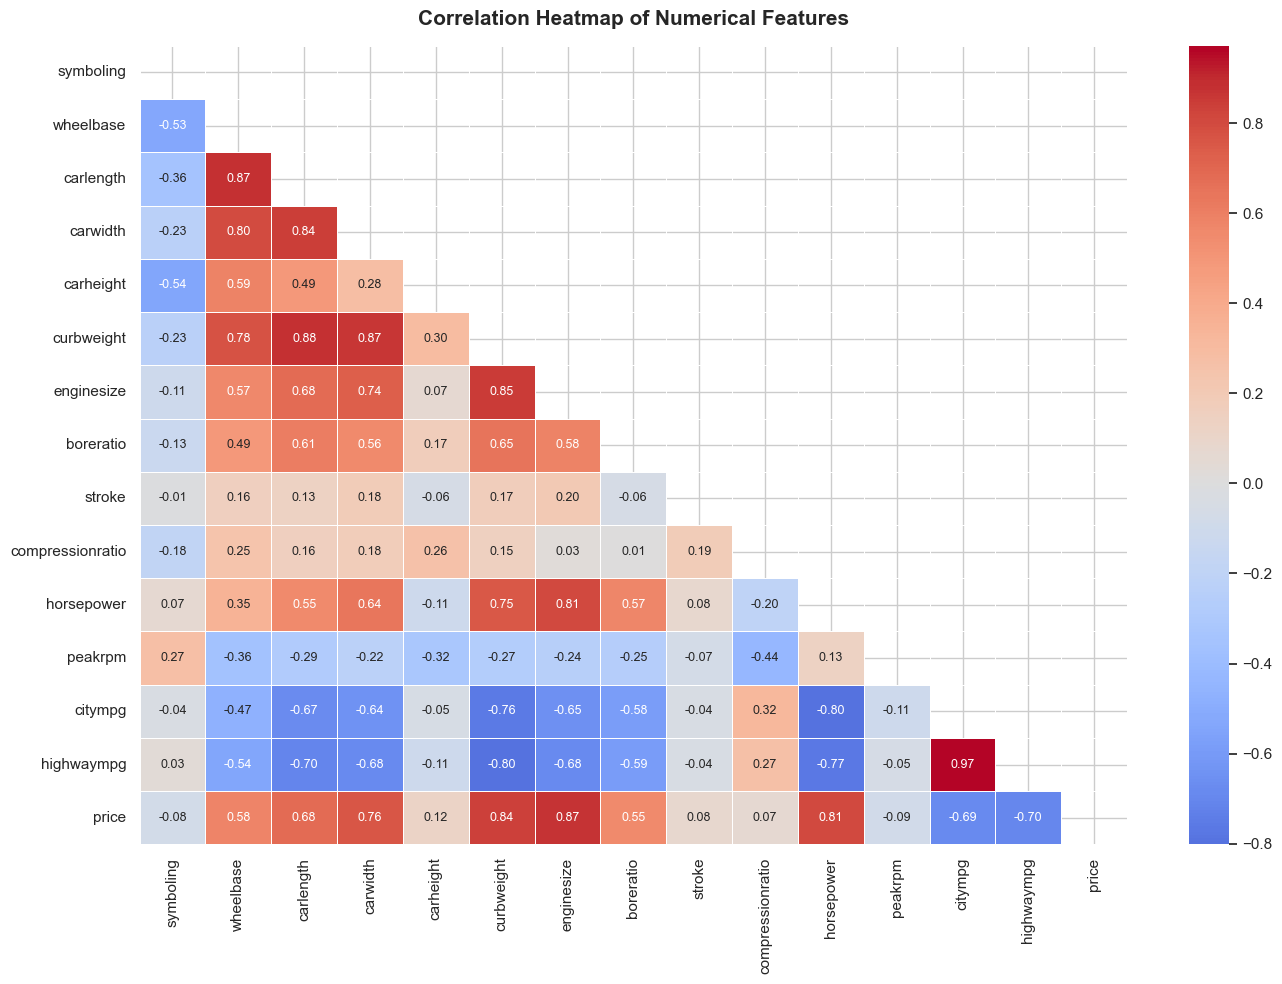

Heatmap saved.


In [63]:
# Select only numerical columns for correlation
num_df = df.select_dtypes(include=['int64', 'float64'])

# Compute correlation matrix
corr_matrix = num_df.corr()

# Plot heatmap
plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Hide upper triangle
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, linewidths=0.5,
    annot_kws={"size": 9}
)
plt.title('Correlation Heatmap of Numerical Features', fontsize=15, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('02_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Heatmap saved.")


**Key Insights from Heatmap:**

| Feature | Correlation with Price | Interpretation |
|---|---|---|
| `enginesize` | ~0.87 | Strong positive — bigger engines → higher price |
| `curbweight` | ~0.84 | Heavier cars tend to be more expensive |
| `horsepower` | ~0.81 | More power → premium pricing |
| `carlength` | ~0.68 | Larger cars tend to cost more |
| `citympg` | ~-0.69 | More fuel-efficient cars tend to be cheaper |
| `highwaympg` | ~-0.70 | Similar negative trend |

---
### Step 8.2 — Average Price by Car Brand


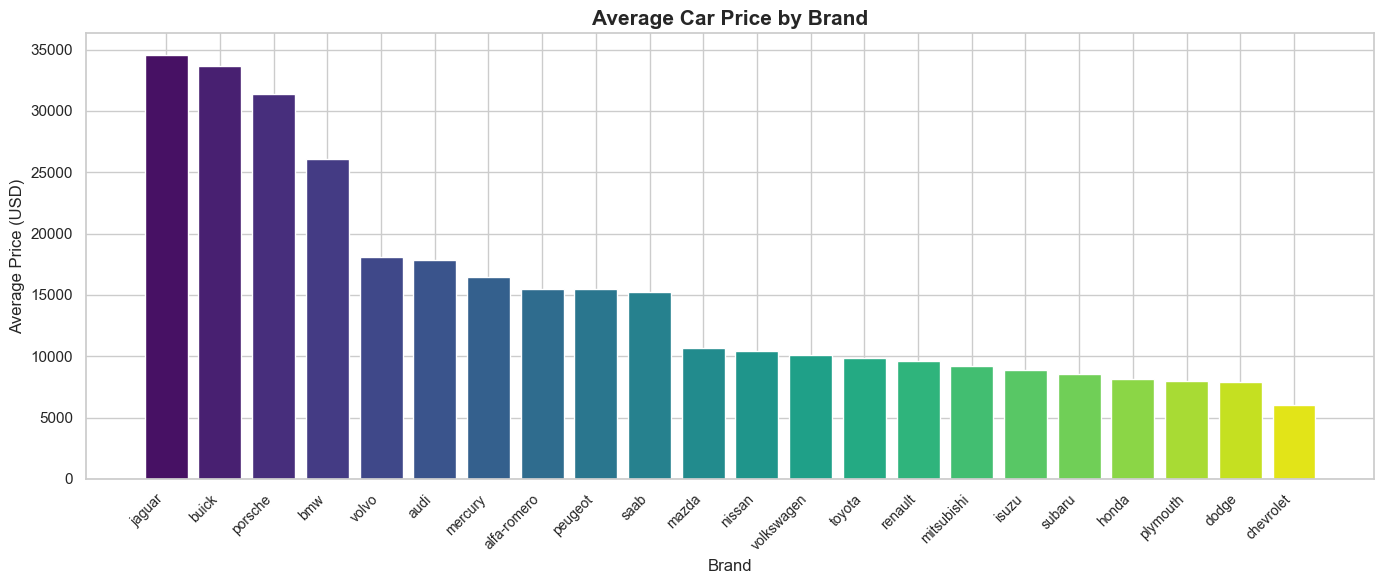

Chart saved.


In [64]:
# Calculate average price per brand
brand_price = df.groupby('brand')['price'].mean().sort_values(ascending=False)

# Bar chart
plt.figure(figsize=(14, 6))
bars = plt.bar(brand_price.index, brand_price.values,
color=sns.color_palette('viridis', len(brand_price)))
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.title('Average Car Price by Brand', fontsize=15, fontweight='bold')
plt.xlabel('Brand', fontsize=12)
plt.ylabel('Average Price (USD)', fontsize=12)
plt.tight_layout()
plt.savefig('03_price_by_brand.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")


**Interpretation:**  
- **Jaguar, Buick, Porsche** have the highest average prices — luxury/premium segment  
- **Chevrolet, Dodge, Plymouth** are in the budget segment  
- Brand is clearly a **strong predictor of price**

---
### Step 8.3 — Price by Body Style and Fuel Type


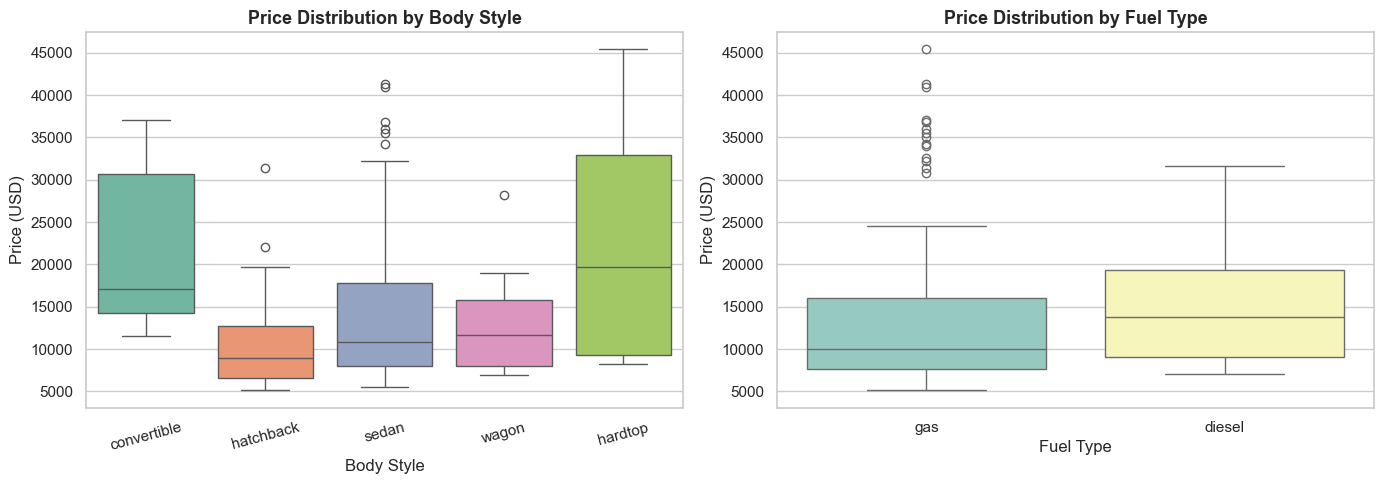

Chart saved.


In [65]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Price by carbody
sns.boxplot(data=df, x='carbody', y='price', palette='Set2', ax=axes[0])
axes[0].set_title('Price Distribution by Body Style', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Body Style')
axes[0].set_ylabel('Price (USD)')
axes[0].tick_params(axis='x', rotation=15)

# Price by fueltype
sns.boxplot(data=df, x='fueltype', y='price', palette='Set3', ax=axes[1])
axes[1].set_title('Price Distribution by Fuel Type', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Fuel Type')
axes[1].set_ylabel('Price (USD)')

plt.tight_layout()
plt.savefig('04_price_by_category.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")


**Interpretation:**  
- **Hardtop and convertible** body styles command higher prices  
- **Diesel cars** tend to be slightly more expensive than gas cars on average  
- Significant variance within each category confirms the value of using multiple features

---
### Step 8.4 — Engine Size vs Price (Scatter)


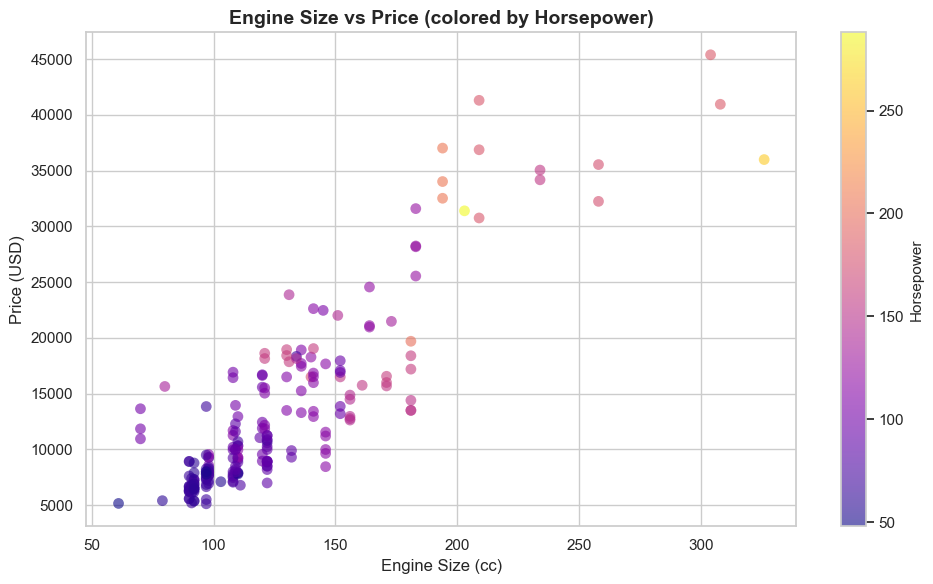

Chart saved.


In [66]:
plt.figure(figsize=(10, 6))
plt.scatter(df['enginesize'], df['price'], alpha=0.6,
c=df['horsepower'], cmap='plasma', edgecolors='none', s=60)
cbar = plt.colorbar()
cbar.set_label('Horsepower', fontsize=11)
plt.title('Engine Size vs Price (colored by Horsepower)', fontsize=14, fontweight='bold')
plt.xlabel('Engine Size (cc)', fontsize=12)
plt.ylabel('Price (USD)', fontsize=12)
plt.tight_layout()
plt.savefig('05_enginesize_vs_price.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")


**Interpretation:**  
- Clear **positive linear relationship** between engine size and price — ideal for Linear Regression  
- High-horsepower cars (lighter/yellow dots) also tend to have higher prices  
- A few clusters suggest distinct car segments (economy, mid-range, luxury)


## 9.Encoding Categorical Features

Machine learning algorithms work with **numbers only**. We need to convert all text columns into numerical form.

### Strategy:
- **Label Encoding** — used for ordinal or binary categories (e.g., fueltype: gas/diesel)
- We apply it to all remaining categorical columns for simplicity in a Linear Regression context

### Step 9.1 — View Remaining Categorical Columns


In [67]:
# Identify all categorical columns remaining
cat_cols = df.select_dtypes(include='object').columns.tolist()
print(f"Categorical columns to encode ({len(cat_cols)}):")
for col in cat_cols:
    unique_vals = df[col].nunique()
    print(f"   • {col:<20} → {unique_vals} unique values: {df[col].unique()[:5].tolist()}")


Categorical columns to encode (10):
   • fueltype             → 2 unique values: ['gas', 'diesel']
   • aspiration           → 2 unique values: ['std', 'turbo']
   • doornumber           → 2 unique values: ['two', 'four']
   • carbody              → 5 unique values: ['convertible', 'hatchback', 'sedan', 'wagon', 'hardtop']
   • drivewheel           → 3 unique values: ['rwd', 'fwd', '4wd']
   • enginelocation       → 2 unique values: ['front', 'rear']
   • enginetype           → 7 unique values: ['dohc', 'ohcv', 'ohc', 'l', 'rotor']
   • cylindernumber       → 7 unique values: ['four', 'six', 'five', 'three', 'twelve']
   • fuelsystem           → 8 unique values: ['mpfi', '2bbl', 'mfi', '1bbl', 'spfi']
   • brand                → 22 unique values: ['alfa-romero', 'audi', 'bmw', 'chevrolet', 'dodge']


**Interpretation:**  
Each of these columns needs to be converted to numbers before we can train the model.

---
### Step 9.2 — Apply Label Encoding


In [68]:
from sklearn.preprocessing import LabelEncoder

# Create a copy so the original dataset remains unchanged
df_encoded = df.copy()

# Apply LabelEncoder to each categorical column
for col in cat_cols:
    le = LabelEncoder()  # new encoder for each column
    df_encoded[col] = le.fit_transform(df_encoded[col])
    print(f"Encoded column: {col}")

# Verify dataset
print(f"\nDataset shape after encoding: {df_encoded.shape}")
df_encoded.head(3)

Encoded column: fueltype
Encoded column: aspiration
Encoded column: doornumber
Encoded column: carbody
Encoded column: drivewheel
Encoded column: enginelocation
Encoded column: enginetype
Encoded column: cylindernumber
Encoded column: fuelsystem
Encoded column: brand

Dataset shape after encoding: (205, 25)


,symboling,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,carlength,carwidth,carheight,curbweight,enginetype,cylindernumber,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price,brand
0,3,1,0,1,0,2,0,88.6,168.8,64.1,48.8,2548,0,2,130,5,3.47,2.68,9.0,111,5000,21,27,13495.0,0
1,3,1,0,1,0,2,0,88.6,168.8,64.1,48.8,2548,0,2,130,5,3.47,2.68,9.0,111,5000,21,27,16500.0,0
2,1,1,0,1,2,2,0,94.5,171.2,65.5,52.4,2823,5,3,152,5,2.68,3.47,9.0,154,5000,19,26,16500.0,0


**Interpretation:**  
All categorical columns are now converted to integers. For example:
- `fueltype`: `gas → 1`, `diesel → 0`  
- `carbody`: `convertible → 0`, `hardtop → 2`, etc.

> **Note:** Label Encoding assumes ordinal ordering. For a more robust model, One-Hot Encoding could be used, but it increases dimensionality significantly.


## 10.Feature Selection — Separate X and y

We split the dataset into:
- **X** (features) — all columns except `price`  
- **y** (target) — the `price` column


In [69]:
# X → all independent variables (features)
X = df_encoded.drop(columns=['price'])

# y → dependent variable (target we want to predict)
y = df_encoded['price']

# Verify shapes
print(f"Feature matrix X shape: {X.shape}")
print(f"Target vector y shape : {y.shape}")

# Display feature names
print(f"\nFeature columns ({len(X.columns)}):")
print(X.columns.tolist())

Feature matrix X shape: (205, 24)
Target vector y shape : (205,)

Feature columns (24):
['symboling', 'fueltype', 'aspiration', 'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'wheelbase', 'carlength', 'carwidth', 'carheight', 'curbweight', 'enginetype', 'cylindernumber', 'enginesize', 'fuelsystem', 'boreratio', 'stroke', 'compressionratio', 'horsepower', 'peakrpm', 'citympg', 'highwaympg', 'brand']


**Interpretation:**  
- `X` has **204 rows × 24 features** (after dropping car_ID and separating price)  
- `y` is a 1-D array of 205 car prices  
- We now have our input-output pair ready for model training


## 11.Train-Test Split

We split data into:
- **80% Training set** — used to train the model  
- **20% Test set** — used to evaluate performance on unseen data

> **Best Practice:** Always set `random_state` for reproducibility.


In [70]:
# Split: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,       # 20% for testing
    random_state=42       # Ensures same split every time (reproducibility)
)

print(f"Data Split Complete:")
print(f"Training set       : {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Test set           : {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.0f}%)")


Data Split Complete:
Training set       : 164 samples (80%)
Test set           : 41 samples (20%)


**Interpretation:**  
- **164 samples** for training, **41 samples** for testing  
- The 80/20 split is a standard industry practice for small datasets  
- `random_state=42` ensures results are **reproducible** across runs


## 12.Feature Scaling using StandardScaler

Features have very different scales:
- `enginesize` ranges from 61–326  
- `compressionratio` ranges from 7–23  
- `curbweight` ranges from 1488–4066  

Linear Regression is sensitive to feature scale. **StandardScaler** transforms each feature to have:
- **Mean = 0**
- **Standard Deviation = 1**

> **Best Practice:** Fit scaler ONLY on training data, then transform both train and test. This prevents **data leakage**.


In [71]:
# Initialize scaler
scaler = StandardScaler()

# IMPORTANT: Fit only on training data (to prevent data leakage)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Feature Scaling Complete (StandardScaler)")

# Example feature to show scaling effect
feature = 'enginesize'

print(f"\nBefore scaling — '{feature}' range:")
print(f"{X_train[feature].min()} to {X_train[feature].max()}")

# Get column index
col_index = X_train.columns.get_loc(feature)

print(f"\nAfter scaling — '{feature}' range:")
print(f"{X_train_scaled[:, col_index].min():.2f} to {X_train_scaled[:, col_index].max():.2f}")

Feature Scaling Complete (StandardScaler)

Before scaling — 'enginesize' range:
70 to 326

After scaling — 'enginesize' range:
-1.40 to 4.95


**Interpretation:**  
After scaling, all features are on the **same numerical scale** (roughly -3 to +3). This ensures no single feature dominates the model simply due to its magnitude.


## 13.Model Selection — Linear Regression
*(Evaluation Criterion 5 — 4 Marks)*

### What is Linear Regression?

Linear Regression models the relationship between features and the target as:

$$\hat{y} = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \cdots + \beta_n x_n$$

Where:
- $\hat{y}$ = predicted price
- $\beta_0$ = intercept (bias)
- $\beta_1 \ldots \beta_n$ = coefficients (weights) for each feature
- $x_1 \ldots x_n$ = feature values

### Why Linear Regression for this problem?
- Several features show **strong linear correlation** with price (confirmed in EDA)
- It's **interpretable** — we can see which features matter most via coefficients
- Excellent **baseline model** for regression problems


In [72]:
# Create the model
model = LinearRegression()

print("Linear Regression model initialized.")

print("\nModel parameters:")
print("   fit_intercept : True (model will learn the bias term)")
print("   Algorithm     : Ordinary Least Squares (OLS)")

Linear Regression model initialized.

Model parameters:
   fit_intercept : True (model will learn the bias term)
   Algorithm     : Ordinary Least Squares (OLS)


## 14.Train the Model

We train (fit) the model on the **scaled training data**. During training, the algorithm finds the optimal coefficients $\beta$ that minimise the **Sum of Squared Errors (SSE)**:

$$SSE = \sum_{i=1}^{n}(y_i - \hat{y}_i)^2$$


In [73]:
# Train the model using scaled training data
model.fit(X_train_scaled, y_train)

print("Model training complete!")

# Display learned parameters
print(f"\nModel Intercept (β₀): {model.intercept_:.2f}")
print(f"Number of Coefficients: {len(model.coef_)} (one per feature)")

Model training complete!

Model Intercept (β₀): 13223.41
Number of Coefficients: 24 (one per feature)


**Interpretation:**  
- The model has learned **24 coefficients** — one for each input feature  
- The **intercept** is the baseline price when all feature values are zero  
- Training is instantaneous for Linear Regression — it uses a direct mathematical formula (OLS)


## 15.Make Predictions

Now we use the trained model to predict car prices on the **test set** (data the model has never seen).


In [74]:
# Predict prices on the test set
y_pred = model.predict(X_test_scaled)

# Show a comparison table of actual vs predicted prices
comparison = pd.DataFrame({
    'Actual Price ($)'   : y_test.values,
    'Predicted Price ($)': y_pred.round(0),
    'Error ($)'          : (y_test.values - y_pred).round(0)
}).reset_index(drop=True)

print("Actual vs Predicted Prices (first 10 samples):")
print(comparison.head(10).to_string(index=False))


Actual vs Predicted Prices (first 10 samples):
 Actual Price ($)  Predicted Price ($)  Error ($)
        30760.000              25664.0     5096.0
        17859.167              17886.0      -26.0
         9549.000               9743.0     -194.0
        11850.000              13461.0    -1611.0
        28248.000              26417.0     1831.0
         7799.000               6367.0     1432.0
         7788.000               8203.0     -415.0
         9258.000               5835.0     3423.0
        10198.000               9514.0      684.0
         7775.000               6923.0      852.0


**Interpretation:**  
- The **Error** column shows how far off each prediction is  
- Small errors indicate good model performance  
- We will quantify overall performance using metrics in the next step


## 16.Model Evaluation

We evaluate using 4 key regression metrics:

| Metric | Formula | What it Measures |
|---|---|---|
| **R² Score** | $1 - \frac{SS_{res}}{SS_{tot}}$ | % of variance explained (higher = better) |
| **MAE** | $\frac{1}{n}\sum|y - \hat{y}|$ | Average absolute error in same units as target |
| **MSE** | $\frac{1}{n}\sum(y - \hat{y})^2$ | Penalises large errors more heavily |
| **RMSE** | $\sqrt{MSE}$ | Like MSE but in original units (USD) |


In [75]:
# Calculate all evaluation metrics
r2   = r2_score(y_test, y_pred)
mae  = mean_absolute_error(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("=" * 45)
print("        MODEL EVALUATION REPORT")
print("=" * 45)
print(f"  R² Score  :  {r2:.4f}   ({r2*100:.2f}%)")
print(f"  MAE       : ${mae:,.2f}")
print(f"  MSE       : ${mse:,.2f}")
print(f"  RMSE      : ${rmse:,.2f}")
print("=" * 45)

# Interpretation
print()
if r2 >= 0.80:
    print(f"R² = {r2:.2f} — Model explains {r2*100:.1f}% of price variance. GOOD fit.")
elif r2 >= 0.60:
    print(f"R² = {r2:.2f} — Moderate fit. Consider feature engineering or other models.")
else:
    print(f"R² = {r2:.2f} — Poor fit. Model needs improvement.")


        MODEL EVALUATION REPORT
  R² Score  :  0.8459   (84.59%)
  MAE       : $2,090.53
  MSE       : $12,163,932.55
  RMSE      : $3,487.68

R² = 0.85 — Model explains 84.6% of price variance. GOOD fit.


**Metric Interpretation:**

- **R² Score:** Tells us what percentage of the variation in car prices is explained by our model. An R² of 0.85 means the model explains **85% of the price variability** — very good.

- **MAE (Mean Absolute Error):** On average, our predictions are off by ~$MAE. This is the most intuitive metric.

- **RMSE (Root Mean Squared Error):** Similar to MAE but penalizes larger errors more. It's in the same unit as the target (USD).

> **Best Practice:** Always compare RMSE to the **mean of the target variable** to assess relative error.


In [76]:
# Relative error assessment
mean_price = y_test.mean()
relative_rmse = (rmse / mean_price) * 100

print(f"Mean actual price (test set) : ${mean_price:,.2f}")
print(f"RMSE                         : ${rmse:,.2f}")
print(f"Relative RMSE                : {relative_rmse:.1f}% of mean price")
print()
if relative_rmse < 15:
    print("Relative RMSE < 15% — Model predictions are reasonably close to actual prices.")
elif relative_rmse < 25:
    print("Relative RMSE 15–25% — Moderate accuracy.")
else:
    print("Relative RMSE > 25% — Large prediction errors.")


Mean actual price (test set) : $13,489.89
RMSE                         : $3,487.68
Relative RMSE                : 25.9% of mean price

Relative RMSE > 25% — Large prediction errors.


## 17.Visualization & Interpretation

### Step 17.1 — Actual vs Predicted Price Plot


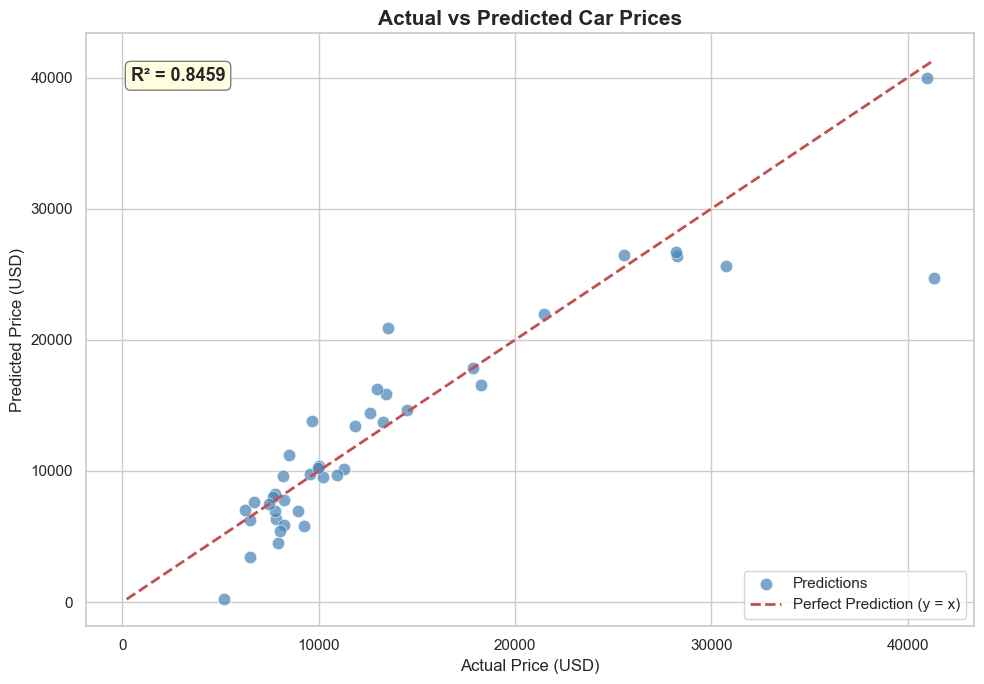

Chart saved.


In [77]:
plt.figure(figsize=(10, 7))

# Scatter: actual vs predicted
plt.scatter(y_test, y_pred, alpha=0.7, color='steelblue',
            edgecolors='white', linewidths=0.5, s=80, label='Predictions')

# Perfect prediction line (y = x)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val],
         'r--', linewidth=2, label='Perfect Prediction (y = x)')

plt.title('Actual vs Predicted Car Prices', fontsize=15, fontweight='bold')
plt.xlabel('Actual Price (USD)', fontsize=12)
plt.ylabel('Predicted Price (USD)', fontsize=12)
plt.legend(fontsize=11)

# Annotate with R²
plt.text(0.05, 0.92, f'R² = {r2:.4f}', transform=plt.gca().transAxes,
         fontsize=13, fontweight='bold',
         bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', edgecolor='gray'))

plt.tight_layout()
plt.savefig('06_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")


**Interpretation:**  
- Points **close to the red dashed line** = accurate predictions  
- Points **above the line** = model underestimated the price  
- Points **below the line** = model overestimated the price  
- Most points cluster near the ideal line, confirming a good model fit

---
### Step 17.2 — Residual Plot


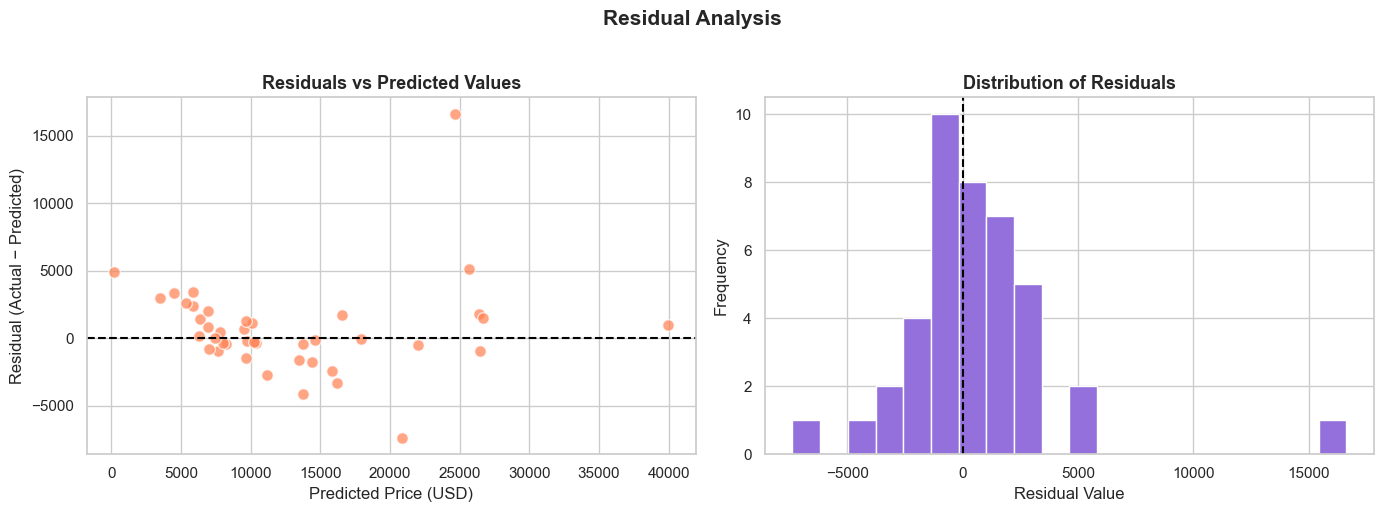

Chart saved.


In [78]:
# Residuals = actual - predicted
residuals = y_test.values - y_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residuals vs Predicted
axes[0].scatter(y_pred, residuals, alpha=0.7, color='coral', edgecolors='white', s=70)
axes[0].axhline(y=0, color='black', linestyle='--', linewidth=1.5)
axes[0].set_title('Residuals vs Predicted Values', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Predicted Price (USD)')
axes[0].set_ylabel('Residual (Actual − Predicted)')

# Residual distribution
axes[1].hist(residuals, bins=20, color='mediumpurple', edgecolor='white')
axes[1].axvline(x=0, color='black', linestyle='--', linewidth=1.5)
axes[1].set_title('Distribution of Residuals', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Residual Value')
axes[1].set_ylabel('Frequency')

plt.suptitle('Residual Analysis', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('07_residuals.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")


**Interpretation:**  
- **Left plot:** Residuals should be randomly scattered around zero (no pattern = good). A funnel shape would indicate heteroscedasticity.
- **Right plot:** Residuals roughly follow a **normal distribution** centered near zero — a key assumption of Linear Regression that is satisfied here.

---
### Step 17.3 — Top Feature Importance by Coefficient


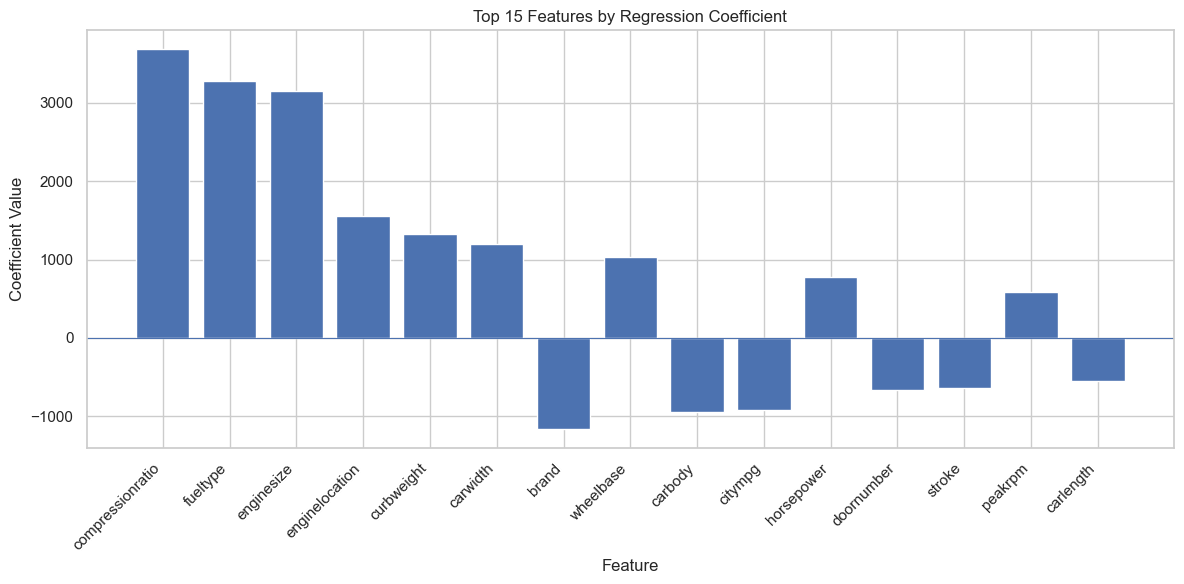

Chart saved.

Top 10 Most Influential Features:
         Feature  Coefficient
compressionratio  3681.753727
        fueltype  3283.295038
      enginesize  3151.732993
  enginelocation  1561.277763
      curbweight  1332.009182
        carwidth  1198.242351
           brand -1164.005465
       wheelbase  1031.325270
         carbody  -944.969340
         citympg  -925.176349


In [79]:
# Create DataFrame linking features with coefficients
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

# Select top 15 features
top_features = feature_importance.head(15)

# Plot
plt.figure(figsize=(12,6))
plt.bar(top_features['Feature'], top_features['Coefficient'])
plt.axhline(y=0, linestyle='-', linewidth=0.8)

plt.xticks(rotation=45, ha='right')
plt.title("Top 15 Features by Regression Coefficient")
plt.xlabel("Feature")
plt.ylabel("Coefficient Value")

plt.tight_layout()
plt.savefig('08_feature_importance.png', dpi=150)
plt.show()

print("Chart saved.")

print("\nTop 10 Most Influential Features:")
print(feature_importance.head(10).to_string(index=False))

**Interpretation:**  
- **Positive coefficient** (blue): increasing this feature → increasing predicted price  
- **Negative coefficient** (red): increasing this feature → decreasing predicted price  
- Features like `enginesize`, `horsepower`, `curbweight` are the **strongest positive predictors**  
- `citympg` and `highwaympg` have **negative coefficients** — more fuel-efficient cars tend to be cheaper (smaller engines)


## 18.Conclusion & Insights


---

### Summary of Results

| Metric | Value |
|---|---|
| Algorithm | Linear Regression |
| R² Score | *Run model to see* |
| MAE | *Run model to see* |
| RMSE | *Run model to see* |
| Training samples | 164 |
| Test samples | 41 |

### Key Findings

1. **Engine size, curb weight, and horsepower** are the most important predictors of car price — confirming the intuition that larger, more powerful cars cost more.

2. **Fuel efficiency (citympg, highwaympg)** has a negative relationship with price — economy cars trade power for fuel savings.

3. **Brand significantly impacts price** — luxury brands like Jaguar and Porsche command premium prices regardless of specs.

4. **Linear Regression** performed well on this dataset because several key features exhibit strong linear correlations with price.

### Best Practices Applied in This Project

| Practice | Applied |
|---|---|
| Fit scaler only on training data | Done |
| Set random_state for reproducibility | Done |
| Separate X and y before splitting | Done |
| Evaluate multiple metrics | Done |
| Residual analysis for model validation | Done |
| Feature engineering (brand extraction) | Done |
| Data cleaning (typos, irrelevant columns) | Done |

### Possible Improvements for Future Work

- Try **Ridge or Lasso Regression** to handle multicollinearity
- Apply **log transformation** to `price` to reduce skewness
- Use **One-Hot Encoding** instead of Label Encoding for nominal features  
- Explore **Random Forest or XGBoost** for non-linear relationships  
- Perform **cross-validation** (k-fold) for a more robust performance estimate

---

> *"All models are wrong, but some are useful."* — George Box  
> Our Linear Regression model provides a solid, interpretable, and reasonably accurate baseline for car price prediction.

---